In [1]:
import torch
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.no_grad().__enter__()

os.environ["TOKENIZERS_PARALLELISM"] = "true"

print(f"Device: {device}")
print(device)

Device: cuda
cuda


In [ ]:
import torch.nn.functional as F
import math
from xpmir.text.huggingface import HFStringTokenizer, HFTokensEncoder
from xpmir.text.encoders import TokenizedTextEncoder
from xpmir.learning.optim import ModuleInitMode
from xpmir.models import AutoModel
from xpmir.text.huggingface import HFModel
from neural.tokenizer import HFStringTokenizerColBERT
from xpmir.neural.interaction.common import DotProductSimilarity
from neural.ColBERT import ColBERTEncoder, HFColBERTTokensEncoder, ColBERTProjectorAdapter, HFTokensEncoderNoType, HFTokensEncoderNoTypeTransform
from neural.sae import (
    SAESPLADE,
    FastTopKSAEAdapter, 
    SAESPLADETokenizedEncoder,
)
from xpmir.text.tokenizers import TokenizerOptions
from xpmir.text.huggingface import (
    HFTokenizer,
    HFTokenizerAdapter,
    HFMaskedLanguageModel,
)
from xpmir.neural.dual import DotDense
from xpmir.neural.splade import MaxAggregation, SpladeTextEncoderV2
from datamaestro_text.data.ir.base import (
    TopicRecord,
    DocumentRecord,
    ScoredItem,
    IDItem,
    create_record,
    TextItem
)
from xpmir.rankers import ScoredDocument
from tqdm import tqdm
from xpmir.text.adapters import TopicTextConverter
import numpy as np
import json
from pathlib import Path


## Load baseline index and compute the posting lists

In [ ]:
from transformers import AutoTokenizer
import pandas as pd
import json
import impact_index

path = Path("/path/to/index")

assert path.is_dir()
data = {}
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

max_term_ix = -1
for ix, f in enumerate(path.glob("**/index/information.cbor")):
    print(f"Loading {str(f.parent.absolute())}")
    tags = json.loads((f.parents[1] / "params.json").read_text())["tags"]
    key = "_".join(f"{key}={value}" for key, value in tags.items())
    index = impact_index.Index.load(str(f.parent.absolute()), False)
    postings = [index.postings(ix).length() for ix in range(index.num_postings())]
    data[f.parents[1].name] = (postings, key)
    max_term_ix = max(max_term_ix, len(postings))

# Build dataframe
df_data = {"Posting length": postings for key, (postings, caption) in data.items()}
for key, (postings, caption) in data.items():
    key = caption or key
    print(f"* {key}")
    while len(postings) < max_term_ix + 1:
        postings.append(0)

df_data["Token ID"] = list(range(max_term_ix + 1))
df_data["term"] = [
    tokenizer.convert_ids_to_tokens(ix) for ix in range(max_term_ix + 1)
]

# df_data = {(caption or key): postings for key, (postings, caption) in data.items()}
# for key, (postings, caption) in data.items():
#     key = caption or key
#     print(f"* {key}")
#     while len(postings) < max_term_ix + 1:
#         postings.append(0)

# df_data["term_ix"] = list(range(max_term_ix + 1))
# df_data["term"] = [
#     tokenizer.convert_ids_to_tokens(ix) for ix in range(max_term_ix + 1)
# ]

baseline_posting_lists = pd.DataFrame(df_data)
# Sort the dataframe by the first column (excluding the header row)
baseline_posting_lists_sorted = baseline_posting_lists.sort_values(by=baseline_posting_lists.columns[0], ascending=False).reset_index(drop=True)
print(baseline_posting_lists_sorted.head())

In [47]:
baseline_posting_lists_sorted[baseline_posting_lists_sorted["Token ID"].isin([1000,1001,1002])]

,Posting length,Token ID,term
1668,144659,1001,#
1734,140602,1002,$
28568,13,1000,""""


## Load SPLADE-SAE checkpoints and compute posting list

In [ ]:
from transformers import AutoTokenizer
import pandas as pd
import json
import impact_index

path = Path("/path/to/index")

assert path.is_dir()
data = {}
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

max_term_ix = -1
for ix, f in enumerate(path.glob("**/index/information.cbor")):
    print(f"Loading {str(f.parent.absolute())}")
    tags = json.loads((f.parents[1] / "params.json").read_text())["tags"]
    key = "_".join(f"{key}={value}" for key, value in tags.items())
    index = impact_index.Index.load(str(f.parent.absolute()), False)
    postings = [index.postings(ix).length() for ix in range(index.num_postings())]
    data[f.parents[1].name] = (postings, key)
    max_term_ix = max(max_term_ix, len(postings))

# Build dataframe
sae_df_data = {"Posting length": postings for key, (postings, caption) in data.items()}
for key, (postings, caption) in data.items():
    key = caption or key
    print(f"* {key}")
    while len(postings) < max_term_ix + 1:
        postings.append(0)

sae_df_data["Latent ID"] = list(range(max_term_ix + 1))
sae_df_data["term"] = [
    tokenizer.convert_ids_to_tokens(ix) for ix in range(max_term_ix + 1)
]
sae_posting_lists = pd.DataFrame(sae_df_data)
# Sort the dataframe by the first column (excluding the header row)
sae_posting_lists_sorted = sae_posting_lists.sort_values(by=sae_posting_lists.columns[0], ascending=False).reset_index(drop=True)
print(sae_posting_lists_sorted.head())

In [ ]:
for ix, f in enumerate(path.glob("**/index/information.cbor")):
    print(f"Loading {str(f.parent.absolute())}")
    tags = json.loads((f.parents[1] / "params.json").read_text())["tags"]
    key = "_".join(f"{key}={value}" for key, value in tags.items())
    index = impact_index.Index.load(str(f.parent.absolute()), False)
    postings = [index.postings(ix).length() for ix in range(index.num_postings())]
    data[f.parents[1].name] = (postings, key)
    max_term_ix = max(max_term_ix, len(postings))
    break

## Build back the mapping latent --> docids and token --> docids

In [ ]:
from tqdm import tqdm
import collections
from transformers import AutoTokenizer
import impact_index

# For the SAE splade
path = Path("/path/to/index")

assert path.is_dir()
data = {}
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

max_term_ix = -1
for ix, f in enumerate(path.glob("**/index/information.cbor")):
    print(f"Loading {str(f.parent.absolute())}")
    tags = json.loads((f.parents[1] / "params.json").read_text())["tags"]
    key = "_".join(f"{key}={value}" for key, value in tags.items())
    index = impact_index.Index.load(str(f.parent.absolute()), False)
    postings = [index.postings(ix).length() for ix in range(index.num_postings())]


token_to_docids = collections.defaultdict(list)
skipped = 0
for ix, length in tqdm(enumerate(postings)):
    if length == 0:
        skipped += 1
        continue
    docs = index.search(py_query={ix:1}, top_k=length)
    for doc in docs:
        token_to_docids[ix].append(doc.docid)

print(f"Skipped {skipped} tokens with zero postings")

In [ ]:
from tqdm import tqdm

# For the SAE splade
path = Path("/path/to/index")

assert path.is_dir()
data = {}
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

max_term_ix = -1
for ix, f in enumerate(path.glob("**/index/information.cbor")):
    print(f"Loading {str(f.parent.absolute())}")
    tags = json.loads((f.parents[1] / "params.json").read_text())["tags"]
    key = "_".join(f"{key}={value}" for key, value in tags.items())
    index = impact_index.Index.load(str(f.parent.absolute()), False)
    postings = [index.postings(ix).length() for ix in range(index.num_postings())]


latent_to_docids = collections.defaultdict(list)
skipped = 0
for ix, length in tqdm(enumerate(postings)):
    if length == 0:
        skipped += 1
        continue
    docs = index.search(py_query={ix:1}, top_k=length)
    for doc in docs:
        latent_to_docids[ix].append(doc.docid)

print(f"Skipped {skipped} latents with zero postings")

In [21]:
small_version = dict()

for i in range(100):
    small_version[i] = latent_to_docids[i]

In [22]:
other_small_version = dict()

for i in range(1000):
    other_small_version[i] = token_to_docids[i]

In [23]:

def jaccard_similarity(a, b):
    a = set(a)
    b = set(b)
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0

def map_posting_lists(vocab_large, vocab_small):
    mapping = {}
    for tok_large, posts_large in tqdm(vocab_large.items()):
        best_tok, best_score = None, -1
        for tok_small, posts_small in vocab_small.items():
            score = jaccard_similarity(posts_large, posts_small)
            if score > best_score:
                best_tok, best_score = tok_small, score
        mapping[tok_large] = (best_tok, best_score)
    return mapping

map_posting_lists(small_version, other_small_version)

100%|██████████| 100/100 [03:24<00:00,  2.04s/it]


{0: (0, 0.0),
 1: (0, 0.0),
 2: (0, 0.0),
 3: (0, 0.0),
 4: (999, 0.0007709051333212407),
 5: (101, 0.003503330499528218),
 6: (0, 0.0),
 7: (999, 2.6337968815844923e-05),
 8: (999, 0.0004901414726523338),
 9: (100, 5.091908956667855e-05),
 10: (999, 0.004675380920508681),
 11: (100, 0.001388980752695284),
 12: (101, 0.001486380413180353),
 13: (0, 0.0),
 14: (0, 0.0),
 15: (0, 0.0),
 16: (999, 0.0003599712023038157),
 17: (0, 0.0),
 18: (999, 5.241090146750524e-05),
 19: (0, 0.0),
 20: (0, 0.0),
 21: (101, 0.001016813741511421),
 22: (999, 0.005201465201465202),
 23: (999, 0.0005732367238374759),
 24: (101, 0.0012335967390138378),
 25: (0, 0.0),
 26: (100, 5.104645227156713e-05),
 27: (0, 0.0),
 28: (0, 0.0),
 29: (100, 0.0021579261194241747),
 30: (101, 7.68344218209758e-05),
 31: (0, 0.0),
 32: (100, 0.0001952362358453729),
 33: (0, 0.0),
 34: (999, 0.002943329352390492),
 35: (0, 0.0),
 36: (0, 0.0),
 37: (101, 0.005226997537515475),
 38: (0, 0.0),
 39: (999, 2.6331033756385276e-05

In [35]:
from datamaestro import prepare_dataset
dataset = prepare_dataset('irds.msmarco-passage.documents')
dataset.documentcount

8841823

In [36]:
import numpy as np
from scipy.sparse import csr_matrix

# Suppose you have doc_count documents
n_docs = 8841823

# Build matrix A (|V_A| x n_docs)
# each row corresponds to a token; column -> doc presence
# Example: from posting lists
rows_A, cols_A = [], []
for i, posts in enumerate(latent_to_docids.values()):
    rows_A.extend([i]*len(posts))
    cols_A.extend(list(posts))
data_A = np.ones(len(rows_A))
A = csr_matrix((data_A, (rows_A, cols_A)), shape=(len(latent_to_docids), n_docs))

# Same for vocab_B
rows_B, cols_B = [], []
for i, posts in enumerate(token_to_docids.values()):
    rows_B.extend([i]*len(posts))
    cols_B.extend(list(posts))
data_B = np.ones(len(rows_B))
B = csr_matrix((data_B, (rows_B, cols_B)), shape=(len(token_to_docids), n_docs))


In [ ]:
from scipy import sparse

# Assume `sparse_matrix` is a scipy sparse matrix, e.g., csr_matrix
# sparse.save_npz('latent_to_docids.npz', A)
# sparse.save_npz('token_to_docids.npz', B)

In [5]:
from scipy import sparse

A = sparse.load_npz('latent_to_docids.npz')
B = sparse.load_npz('token_to_docids.npz')

## Jaccard Similarities

In [6]:
# Intersection count (dot product of binary vectors)
inter = A.dot(B.T).toarray()

# Row and col sums = set sizes
size_A = np.array(A.sum(axis=1))
size_B = np.array(B.sum(axis=1))

# Broadcast to compute union sizes
union = size_A + size_B.T - inter

# Jaccard similarity
jaccard = inter / union
jaccard[np.isnan(jaccard)] = 0

/tmp/ipykernel_3599697/2729663059.py:12: RuntimeWarning: invalid value encountered in divide
  jaccard = inter / union


In [8]:
np.save('jaccard_matrix.npy', jaccard)

In [10]:
import numpy as np
top_k = 3

top_idx = np.argsort(jaccard, axis=1)[:, -top_k:][:, ::-1]  # shape: (num_latents, 3)

# Corresponding Jaccard scores
top_scores = np.take_along_axis(jaccard, top_idx, axis=1)  # shape: (num_latents, 3)

# Map latent IDs to list of (token ID, score) tuples
latent_ids = list(latent_to_docids.keys())
token_ids = list(token_to_docids.keys())

mapping_top3 = {
    latent_ids[i]: [
        (token_ids[top_idx[i, j]], top_scores[i, j])
        for j in range(top_k)
    ]
    for i in range(len(latent_ids))
}


In [11]:
import pandas as pd

# Build DataFrame with lists of token IDs and scores
df_top3 = pd.DataFrame([
    {
        "Latent ID": latent_id,
        "Token IDs": [t for t, s in top_list],             # list of token IDs
        "Jaccard Similarities": [s for t, s in top_list]  # list of corresponding scores
    }
    for latent_id, top_list in mapping_top3.items()
])

# Save to CSV
df_top3.to_csv("top3_jaccard_similarity.csv", index=False)

print(df_top3)

       Latent ID              Token IDs  \
0              0  [17087, 17520, 25523]   
1              2  [26550, 24691, 19074]   
2              4  [19292, 26222, 10398]   
3              5   [10019, 4224, 15975]   
4              6  [10926, 20406, 16212]   
...          ...                    ...   
54585      65528    [6404, 12131, 8202]   
54586      65530   [12367, 6727, 21672]   
54587      65531  [10765, 26500, 13073]   
54588      65534   [10247, 5955, 11433]   
54589      65535  [16064, 15163, 15225]   

                                    Jaccard Similarities  
0      [0.000273972602739726, 0.0002133560913164071, ...  
1      [0.0196078431372549, 0.0009099181073703367, 0....  
2      [0.13114915387642662, 0.05240108728480822, 0.0...  
3      [0.32532584879556753, 0.2600809739904635, 0.15...  
4      [0.000502008032128514, 0.00033277870216306157,...  
...                                                  ...  
54585  [0.00012285012285012285, 0.0001034875297526648...  
54586  [0.1

In [5]:
import pandas as pd
df = pd.read_csv("top_jaccard_similarity_token_per_latent.csv")

df

,Latent ID,Token ID,Jaccard Similarity
0,0,17087,0.000274
1,2,26550,0.019608
2,4,19292,0.131149
3,5,10019,0.325326
4,6,10926,0.000502
...,...,...,...
54603,71,100,0.000000
54604,77,100,0.000000
54605,83,100,0.000000
54606,87,100,0.000000


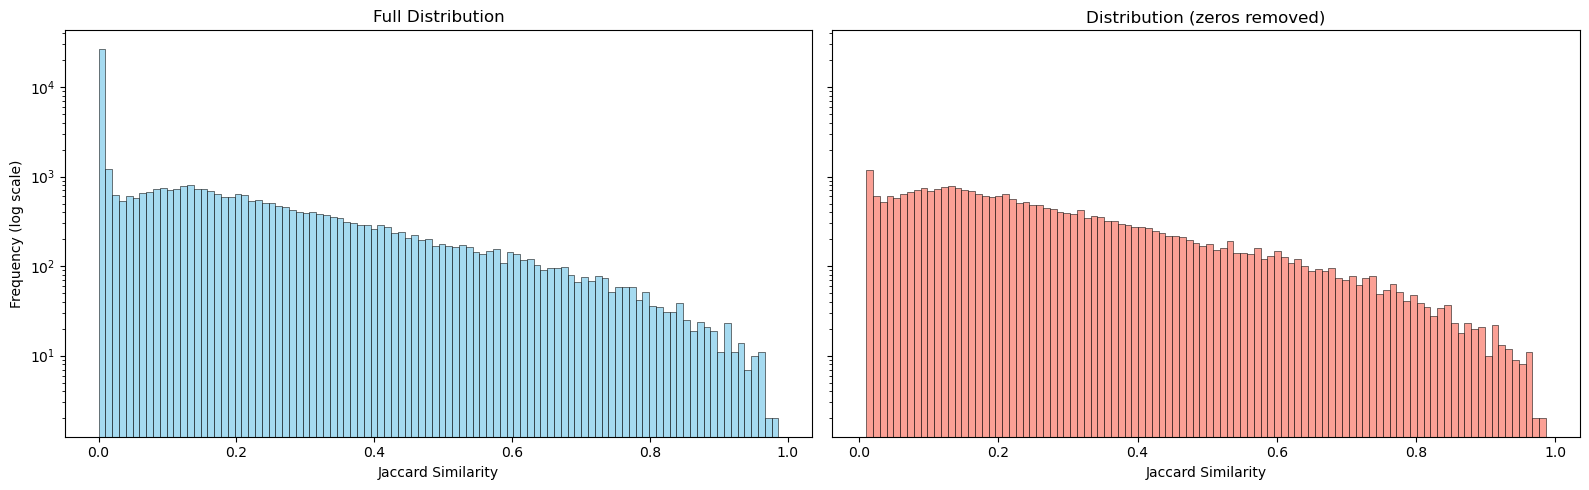

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out zeros
df_nonzero = df[df['Jaccard Similarity'] > 0.01]

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# --- Left: full distribution ---
sns.histplot(df['Jaccard Similarity'], bins=100, color='skyblue', kde=False, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_xlabel('Jaccard Similarity')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Full Distribution')

# --- Right: filtered distribution (zeros removed) ---
sns.histplot(df_nonzero['Jaccard Similarity'], bins=100, color='salmon', kde=False, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel('Jaccard Similarity')
axes[1].set_title('Distribution (zeros removed)')

plt.tight_layout()
plt.show()


## TOP Jaccard similarity between each token and a latent

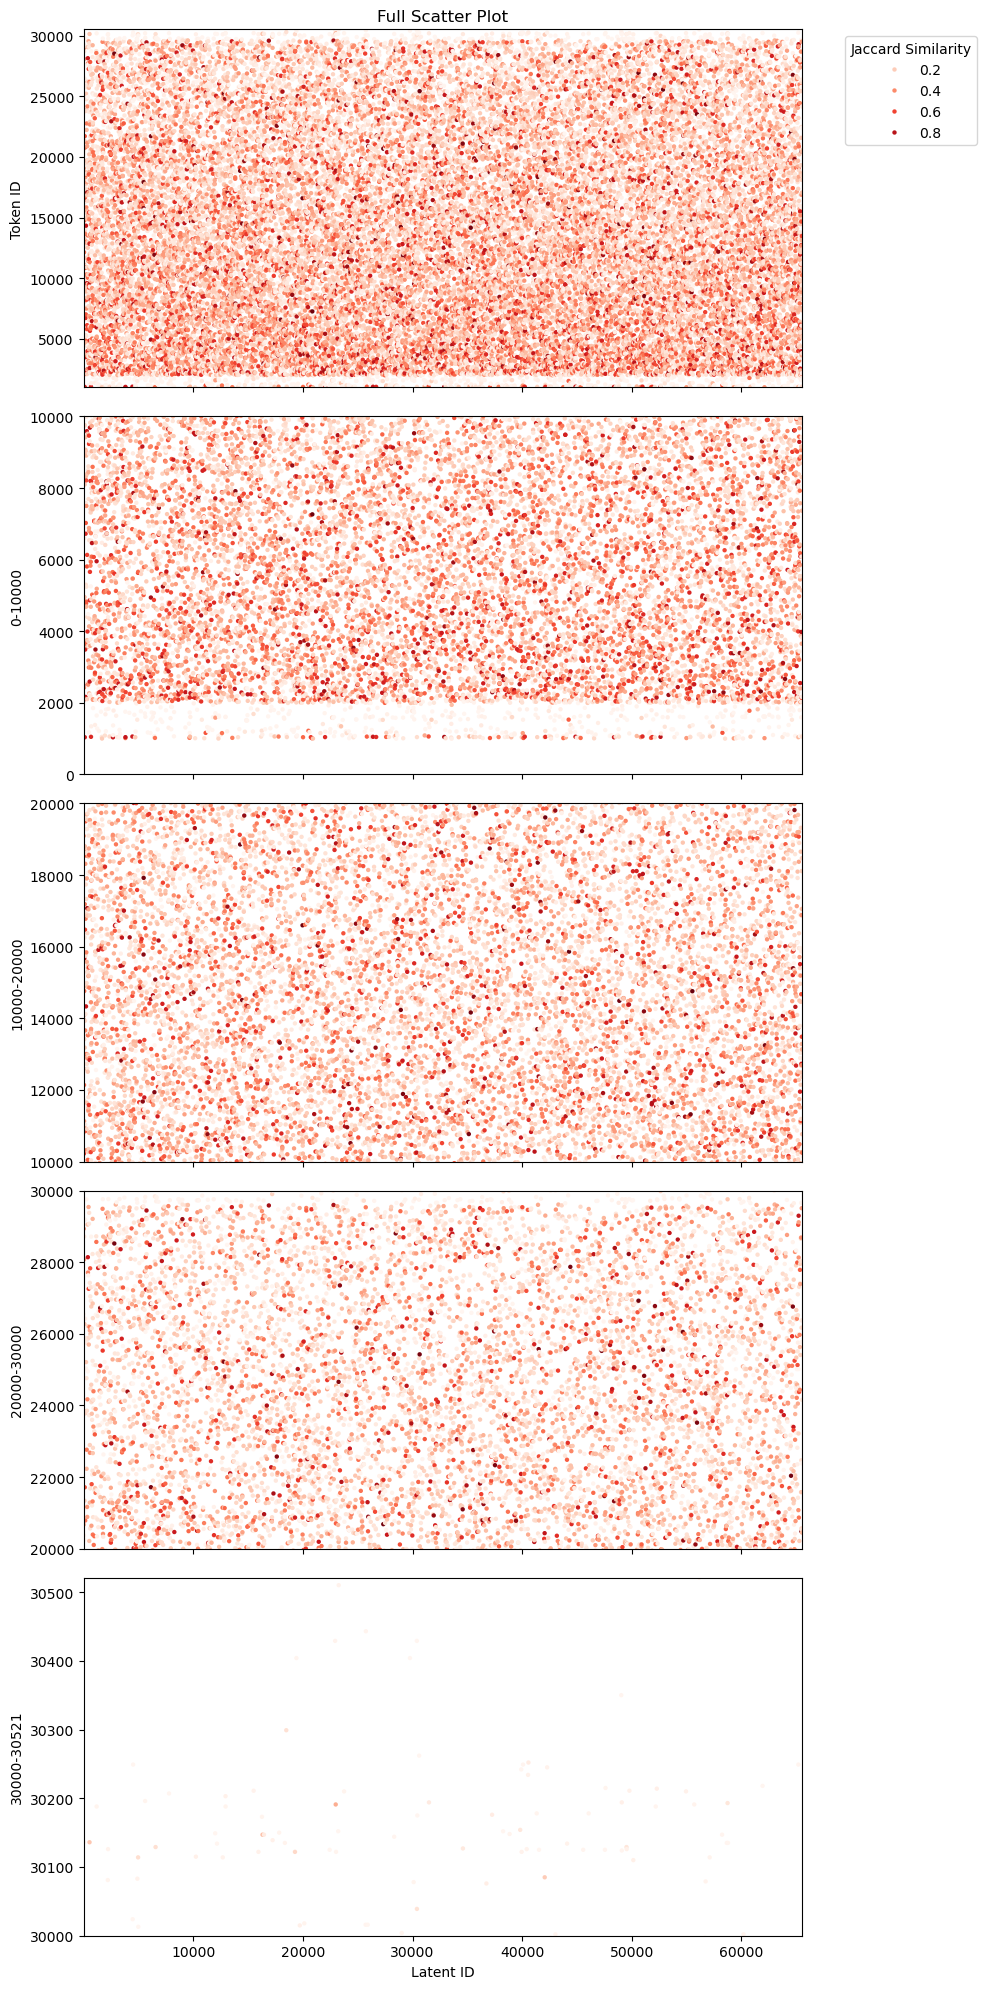

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter points above threshold
df_filtered = df[df['Jaccard Similarity'] > 0.01]

# Determine zoom ranges (per 10k on y-axis)
ymax = df_filtered['Token ID'].max()
zoom_step = 10000
zoom_ranges = [(start, min(start + zoom_step, ymax)) for start in range(0, int(ymax)+1, zoom_step)]

# Create vertical subplots: 1 full plot + len(zoom_ranges) zoomed plots
n_zoom = len(zoom_ranges)
fig, axes = plt.subplots(n_zoom + 1, 1, figsize=(10, 4*(n_zoom+1)), sharex=True)

# --- Full scatter plot on top ---
sns.scatterplot(
    data=df_filtered,
    x='Latent ID',
    y='Token ID',
    hue='Jaccard Similarity',
    palette='Reds',
    s=10,
    edgecolor='none',
    ax=axes[0]
)
axes[0].set_ylabel('Token ID')
axes[0].set_title('Full Scatter Plot')
axes[0].legend(title='Jaccard Similarity', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].margins(x=0, y=0)

# --- Zoomed plots below ---
for ax, (ymin, ymax) in zip(axes[1:], zoom_ranges):
    sns.scatterplot(
        data=df_filtered,
        x='Latent ID',
        y='Token ID',
        hue='Jaccard Similarity',
        palette='Reds',
        s=10,
        edgecolor='none',
        ax=ax,
        legend=False  # avoid repeated legends
    )
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(f'{ymin}-{ymax}')
    ax.margins(x=0)

axes[-1].set_xlabel('Latent ID')

plt.tight_layout()
plt.show()


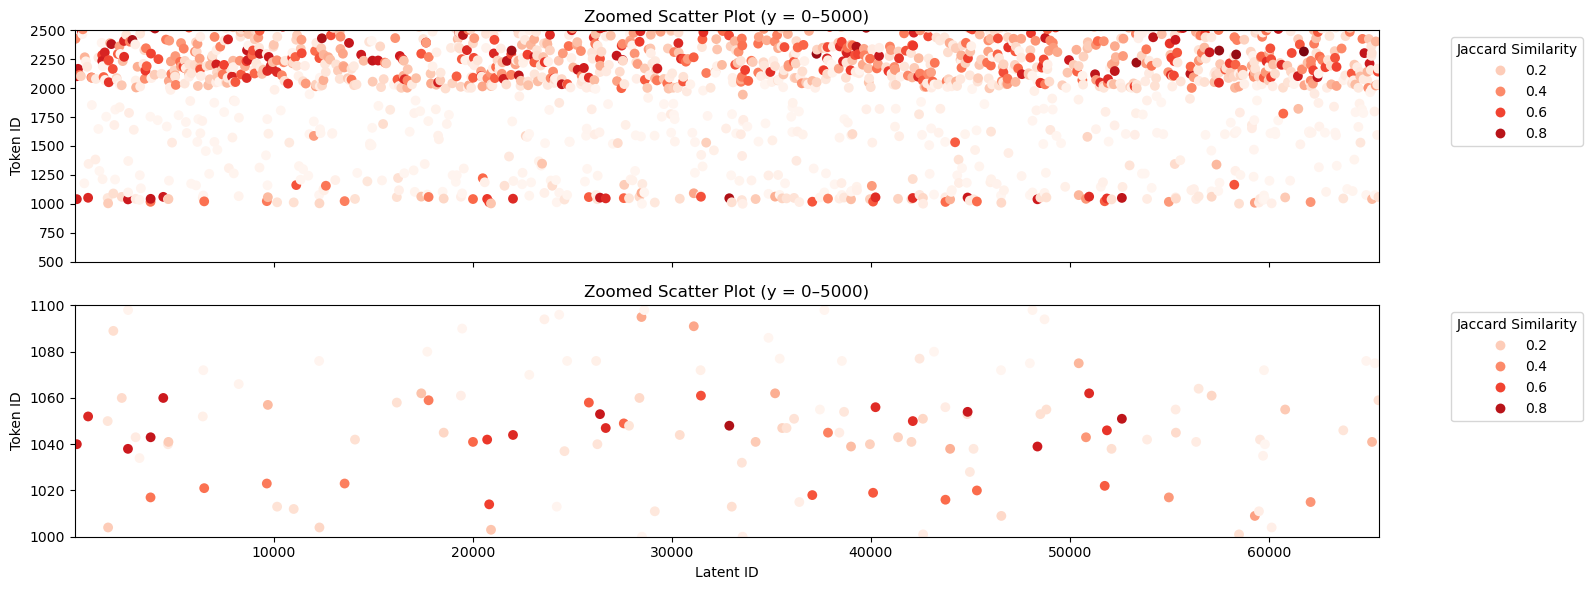

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter points above threshold
df_filtered = df[df['Jaccard Similarity'] > 0.01]

# Create two subplots side by side
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# --- Zoomed-in scatter plot on y-axis 0–5000 ---
sns.scatterplot(
    data=df_filtered,
    x='Latent ID',
    y='Token ID',
    hue='Jaccard Similarity',
    palette='Reds',
    s=50,
    edgecolor='none',
    ax=axes[0]
)
axes[0].set_xlabel('Latent ID')
axes[0].set_ylabel('Token ID')
axes[0].set_title('Zoomed Scatter Plot (y = 0–5000)')
axes[0].set_ylim(500, 2500)  # zoom on y-axis
axes[0].legend(title='Jaccard Similarity', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].margins(x=0)

sns.scatterplot(
    data=df_filtered,
    x='Latent ID',
    y='Token ID',
    hue='Jaccard Similarity',
    palette='Reds',
    s=50,
    edgecolor='none',
    ax=axes[1]
)
axes[1].set_xlabel('Latent ID')
axes[1].set_ylabel('Token ID')
axes[1].set_title('Zoomed Scatter Plot (y = 0–5000)')
axes[1].set_ylim(1000, 1100)  # zoom on y-axis
axes[1].legend(title='Jaccard Similarity', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].margins(x=0)

# Adjust layout
plt.tight_layout()
plt.show()


### Focus on the area around token ids 1000 and 1100

In [28]:
from transformers import AutoTokenizer
import pandas as pd

# Load the tokenizer (replace with your model)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Filter high Jaccard similarities in the range 1000–1100
token_range_df = df[
    (df['Token ID'] >= 1000) &
    (df['Token ID'] <= 1100) &
    (df['Jaccard Similarity'] > 0.01)
]

# Count distinct Latent IDs per Token ID
token_counts = token_range_df.groupby('Token ID')['Latent ID'].nunique().reset_index()
token_counts.rename(columns={'Latent ID': 'High_Sim_Latent_Count'}, inplace=True)

# Map Token ID to token string
token_counts['Token'] = token_counts['Token ID'].apply(lambda x: tokenizer.convert_ids_to_tokens(x))

# Reorder columns for readability
token_counts = token_counts[['Token ID', 'Token', 'High_Sim_Latent_Count']]

# Sort by High_Sim_Latent_Count descending
token_counts = token_counts.sort_values(by='High_Sim_Latent_Count', ascending=False).reset_index(drop=True)

print(token_counts)


    Token ID Token  High_Sim_Latent_Count
0       1041     e                      6
1       1076     ª                      5
2       1040     d                      5
3       1098     ð                      4
4       1038     b                      4
..       ...   ...                    ...
59      1057     u                      1
60      1018     4                      1
61      1028     >                      1
62      1016     2                      1
63      1014     0                      1

[64 rows x 3 columns]


In [26]:
from transformers import AutoTokenizer
import pandas as pd

# Load the tokenizer (replace with your model)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Filter for high Jaccard similarities (>0.4)
high_sim_df = df[df['Jaccard Similarity'] > 0.01]

# Count distinct Latent IDs per Token ID
token_counts_all = high_sim_df.groupby('Token ID')['Latent ID'].nunique().reset_index()
token_counts_all.rename(columns={'Latent ID': 'High_Sim_Latent_Count'}, inplace=True)

# Map Token ID to token string
token_counts_all['Token'] = token_counts_all['Token ID'].apply(lambda x: tokenizer.convert_ids_to_tokens(x))

# Reorder columns for readability
token_counts_all = token_counts_all[['Token ID', 'Token', 'High_Sim_Latent_Count']]

# Sort by High_Sim_Latent_Count descending and take top 10
top10_tokens = token_counts_all.sort_values(by='High_Sim_Latent_Count', ascending=False).head(50).reset_index(drop=True)

print(top10_tokens)


    Token ID         Token  High_Sim_Latent_Count
0       2237          town                     15
1       3976         price                     14
2       2003            is                     13
3       3883       actress                     13
4       7555      playoffs                     11
5       2774         songs                     11
6      14172         feeds                     11
7       6462        button                     10
8       3574       meaning                     10
9       4633       weather                      9
10     11988       surname                      9
11      8030      symptoms                      9
12     25517     vertebrae                      9
13      2201         album                      9
14      3903         sides                      8
15      2034         first                      8
16     29201        ##dict                      8
17     20992   medications                      8
18     25557        ##riam                      8


So far, we mapped tokens with latents based on their posting lists similarities. We then printed for each token, with how many latents in averaged they shared highly similar posting lists.
We also computed the average nb of tokens with posting lists highly similar to each latent, involved in these count.

In [6]:
from transformers import AutoTokenizer
import pandas as pd
pd.set_option('display.width', None)           # No wrapping based on width
pd.set_option('display.max_columns', None)     # Show all columns

# Load the tokenizer (replace with your model)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Filter for high Jaccard similarities (>0.4)
high_sim_df = df[df['Jaccard Similarity'] > 0.01]

# Count distinct Latent IDs per Token ID
token_counts_all = high_sim_df.groupby('Token ID')['Latent ID'].nunique().reset_index()
token_counts_all.rename(columns={'Latent ID': 'High_Sim_Latent_Count'}, inplace=True)

# Map Token ID to token string
token_counts_all['Token'] = token_counts_all['Token ID'].apply(lambda x: tokenizer.convert_ids_to_tokens(x))

# Reorder columns for readability
token_counts_all = token_counts_all[['Token ID', 'Token', 'High_Sim_Latent_Count']]

# --- Compute Averaged High Sim Token Count per Latent ---
# 1. Count high-sim Tokens per Latent
latent_high_sim_counts = high_sim_df.groupby('Latent ID')['Token ID'].nunique().reset_index()
latent_high_sim_counts.rename(columns={'Token ID': 'High_Sim_Token_Count'}, inplace=True)

# 2. For each Token, get the Latents involved
token_latents = high_sim_df.groupby('Token ID')['Latent ID'].apply(list).reset_index()

# 3. Compute average high-sim Tokens per Latent for each Token
def compute_avg(row):
    latents = row['Latent ID']
    counts = latent_high_sim_counts[latent_high_sim_counts['Latent ID'].isin(latents)]['High_Sim_Token_Count']
    return counts.mean()

token_latents['Averaged High Sim Token Count per Latent'] = token_latents.apply(compute_avg, axis=1)

# Merge back to token_counts_all
final_df = pd.merge(token_counts_all, token_latents[['Token ID', 'Averaged High Sim Token Count per Latent']], on='Token ID')

# Sort descending by High_Sim_Latent_Count and take top 10
print(final_df.sort_values(by='High_Sim_Latent_Count', ascending=False).head(50).reset_index(drop=True).to_string(index=False, line_width=1000))

print(token_latents['Averaged High Sim Token Count per Latent'].max())


 Token ID        Token  High_Sim_Latent_Count  Averaged High Sim Token Count per Latent
     2237         town                     15                                       1.0
     3976        price                     14                                       1.0
     2003           is                     13                                       1.0
     3883      actress                     13                                       1.0
     7555     playoffs                     11                                       1.0
     2774        songs                     11                                       1.0
    14172        feeds                     11                                       1.0
     6462       button                     10                                       1.0
     3574      meaning                     10                                       1.0
     4633      weather                      9                                       1.0
    11988      surname          

### Further check the average jaccard similarity across latents

In [13]:
from transformers import AutoTokenizer
import pandas as pd

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

# Load the tokenizer (replace with your model)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Filter for high Jaccard similarities (>0.01)
high_sim_df = df[df['Jaccard Similarity'] > 0.01]

# Count distinct Latent IDs per Token ID
token_counts_all = (
    high_sim_df.groupby('Token ID')['Latent ID']
    .nunique()
    .reset_index()
    .rename(columns={'Latent ID': 'High_Sim_Latent_Count'})
)

# 🔹 Compute average Jaccard similarity per Token ID
token_avg_jaccard = (
    high_sim_df.groupby('Token ID')['Jaccard Similarity']
    .mean()
    .reset_index()
    .rename(columns={'Jaccard Similarity': 'Avg_Jaccard_Similarity'})
)

# Map Token ID to token string
token_counts_all['Token'] = token_counts_all['Token ID'].apply(lambda x: tokenizer.convert_ids_to_tokens(x))

# Reorder columns for readability
token_counts_all = token_counts_all[['Token ID', 'Token', 'High_Sim_Latent_Count']]

# --- Compute Averaged High Sim Token Count per Latent ---
latent_high_sim_counts = (
    high_sim_df.groupby('Latent ID')['Token ID']
    .nunique()
    .reset_index()
    .rename(columns={'Token ID': 'High_Sim_Token_Count'})
)

token_latents = (
    high_sim_df.groupby('Token ID')['Latent ID']
    .apply(list)
    .reset_index()
)

def compute_avg(row):
    latents = row['Latent ID']
    counts = latent_high_sim_counts[latent_high_sim_counts['Latent ID'].isin(latents)]['High_Sim_Token_Count']
    return counts.mean()

token_latents['Averaged High Sim Token Count per Latent'] = token_latents.apply(compute_avg, axis=1)

# Merge everything
final_df = (
    token_counts_all
    .merge(token_latents[['Token ID', 'Averaged High Sim Token Count per Latent']], on='Token ID')
    .merge(token_avg_jaccard, on='Token ID')
)

# Sort descending by High_Sim_Latent_Count
final_df = final_df.sort_values(by='High_Sim_Latent_Count', ascending=False).reset_index(drop=True)

# Display top 50 tokens
print(final_df.head(50).to_string(index=False, line_width=1000))

 Token ID        Token  High_Sim_Latent_Count  Averaged High Sim Token Count per Latent  Avg_Jaccard_Similarity
     2237         town                     15                                       1.0                0.257216
     3976        price                     14                                       1.0                0.333879
     2003           is                     13                                       1.0                0.094345
     3883      actress                     13                                       1.0                0.211519
     7555     playoffs                     11                                       1.0                0.203080
     2774        songs                     11                                       1.0                0.231354
    14172        feeds                     11                                       1.0                0.066732
     6462       button                     10                                       1.0                0

In [55]:
from transformers import AutoTokenizer
import pandas as pd

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# --- Filter and compute base counts ---
high_sim_df = df[df['Jaccard Similarity'] > 0.01]

# Count distinct Latents per Token
token_counts_all = (
    high_sim_df.groupby('Token ID')['Latent ID']
    .nunique()
    .reset_index()
    .rename(columns={'Latent ID': 'High_Sim_Latent_Count'})
)

# Compute average Jaccard similarity per Token
token_avg_jaccard = (
    high_sim_df.groupby('Token ID')['Jaccard Similarity']
    .mean()
    .reset_index()
    .rename(columns={'Jaccard Similarity': 'Avg_Jaccard_Similarity'})
)

# --- Compute Averaged High Sim Token Count per Latent ---
latent_high_sim_counts = (
    high_sim_df.groupby('Latent ID')['Token ID']
    .nunique()
    .reset_index()
    .rename(columns={'Token ID': 'High_Sim_Token_Count'})
)

token_latents = (
    high_sim_df.groupby('Token ID')['Latent ID']
    .apply(list)
    .reset_index()
)

def compute_avg(row):
    latents = row['Latent ID']
    counts = latent_high_sim_counts[latent_high_sim_counts['Latent ID'].isin(latents)]['High_Sim_Token_Count']
    return counts.mean()

token_latents['Averaged High Sim Token Count per Latent'] = token_latents.apply(compute_avg, axis=1)

# --- Compute average latent posting list lengths per Token ---
# Merge latent posting lengths into high_sim_df
high_sim_with_posting = high_sim_df.merge(sae_posting_lists_sorted, on='Latent ID', how='left')

# Compute average latent posting length per Token
avg_latent_posting_per_token = (
    high_sim_with_posting.groupby('Token ID')['Posting length']
    .mean()
    .reset_index()
    .rename(columns={'Posting length': 'Avg_Latent_Posting_Length'})
)

std_latent_posting_per_token = (
    high_sim_with_posting.groupby('Token ID')['Posting length']
    .std()
    .reset_index()
    .rename(columns={'Posting length': 'Std_Latent_Posting_Length'})
)

max_latent_posting_per_token = (
    high_sim_with_posting.groupby('Token ID')['Posting length']
    .max()
    .reset_index()
    .rename(columns={'Posting length': 'Max_Latent_Posting_Length'})
)

min_latent_posting_per_token = (
    high_sim_with_posting.groupby('Token ID')['Posting length']
    .min()
    .reset_index()
    .rename(columns={'Posting length': 'Min_Latent_Posting_Length'})
)

# --- Merge all together ---
final_df = (
    token_counts_all
    .merge(token_latents[['Token ID', 'Averaged High Sim Token Count per Latent']], on='Token ID')
    .merge(token_avg_jaccard, on='Token ID')
    .merge(baseline_posting_lists_sorted, on='Token ID', how='left')
    .merge(avg_latent_posting_per_token, on='Token ID', how='left')
    .merge(std_latent_posting_per_token, on='Token ID', how='left')
    .merge(max_latent_posting_per_token, on='Token ID', how='left')
    .merge(min_latent_posting_per_token, on='Token ID', how='left')
)

# Add Token string for readability
final_df['Token'] = final_df['Token ID'].apply(lambda x: tokenizer.convert_ids_to_tokens(x))

# Reorder and sort
final_df = final_df[
    [
        'Token ID',
        'Token',
        'High_Sim_Latent_Count',
        'Averaged High Sim Token Count per Latent',
        'Avg_Jaccard_Similarity',
        'Posting length',
        'Avg_Latent_Posting_Length',
        'Std_Latent_Posting_Length',
        'Max_Latent_Posting_Length',
        'Min_Latent_Posting_Length'
    ]
].sort_values(by='High_Sim_Latent_Count', ascending=False).reset_index(drop=True)

final_df = final_df.round(3)

# Display top tokens
print(final_df.head(50).to_string(index=False, line_width=1000))


 Token ID        Token  High_Sim_Latent_Count  Averaged High Sim Token Count per Latent  Avg_Jaccard_Similarity  Posting length  Avg_Latent_Posting_Length  Std_Latent_Posting_Length  Max_Latent_Posting_Length  Min_Latent_Posting_Length
     2237         town                     15                                       1.0                   0.257          542846                 315355.267                 115430.206                     595363                     137382
     3976        price                     14                                       1.0                   0.334          598894                 276469.000                  90789.210                     454923                      89865
     2003           is                     13                                       1.0                   0.094          893003                 256786.077                 126641.174                     490369                      51459
     3883      actress                     13           

## Special tokens ?

In [52]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Special tokens
special_tokens = ['[PAD]', '[CLS]', '[SEP]']
special_token_ids = tokenizer.convert_tokens_to_ids(special_tokens)

# Check presence in df
for token, token_id in zip(special_tokens, special_token_ids):
    present = token_id in df['Token ID'].values
    print(f"{token} (ID {token_id}) present in DataFrame? {present}")


[PAD] (ID 0) present in DataFrame? False
[CLS] (ID 101) present in DataFrame? False
[SEP] (ID 102) present in DataFrame? False


## Study more precisely the relationships between the latents and the tokens (is there really a one to one mapping between each latent and the tokens and a one-to-many mapping between tokens to latents?)

In [1]:
import pandas as pd
df = pd.read_csv("top3_jaccard_similarity.csv")

df

,Latent ID,Token IDs,Jaccard Similarities
0,0,"[17087, 17520, 25523]","[0.000273972602739726, 0.0002133560913164071, ..."
1,2,"[26550, 24691, 19074]","[0.0196078431372549, 0.0009099181073703367, 0...."
2,4,"[19292, 26222, 10398]","[0.13114915387642662, 0.05240108728480822, 0.0..."
3,5,"[10019, 4224, 15975]","[0.32532584879556753, 0.2600809739904635, 0.15..."
4,6,"[10926, 20406, 16212]","[0.000502008032128514, 0.00033277870216306157,..."
...,...,...,...
54585,65528,"[6404, 12131, 8202]","[0.00012285012285012285, 0.0001034875297526648..."
54586,65530,"[12367, 6727, 21672]","[0.1751650770359501, 0.12676728250498742, 0.11..."
54587,65531,"[10765, 26500, 13073]","[0.21779559802081555, 0.1405803638550594, 0.08..."
54588,65534,"[10247, 5955, 11433]","[0.44119475879845793, 0.43928112628791655, 0.0..."


In [2]:
df["Diff between Top1 and Top2"] = df['Jaccard Similarities'].apply(lambda x: eval(x)[0] - eval(x)[1] if isinstance(eval(x), list) and len(eval(x)) > 1 else None)
df['Top1_Jaccard'] = df['Jaccard Similarities'].apply(lambda x: eval(x)[0] if isinstance(eval(x), list) and len(eval(x)) > 0 else None)
df

,Latent ID,Token IDs,Jaccard Similarities,Diff between Top1 and Top2,Top1_Jaccard
0,0,"[17087, 17520, 25523]","[0.000273972602739726, 0.0002133560913164071, ...",0.000061,0.000274
1,2,"[26550, 24691, 19074]","[0.0196078431372549, 0.0009099181073703367, 0....",0.018698,0.019608
2,4,"[19292, 26222, 10398]","[0.13114915387642662, 0.05240108728480822, 0.0...",0.078748,0.131149
3,5,"[10019, 4224, 15975]","[0.32532584879556753, 0.2600809739904635, 0.15...",0.065245,0.325326
4,6,"[10926, 20406, 16212]","[0.000502008032128514, 0.00033277870216306157,...",0.000169,0.000502
...,...,...,...,...,...
54585,65528,"[6404, 12131, 8202]","[0.00012285012285012285, 0.0001034875297526648...",0.000019,0.000123
54586,65530,"[12367, 6727, 21672]","[0.1751650770359501, 0.12676728250498742, 0.11...",0.048398,0.175165
54587,65531,"[10765, 26500, 13073]","[0.21779559802081555, 0.1405803638550594, 0.08...",0.077215,0.217796
54588,65534,"[10247, 5955, 11433]","[0.44119475879845793, 0.43928112628791655, 0.0...",0.001914,0.441195


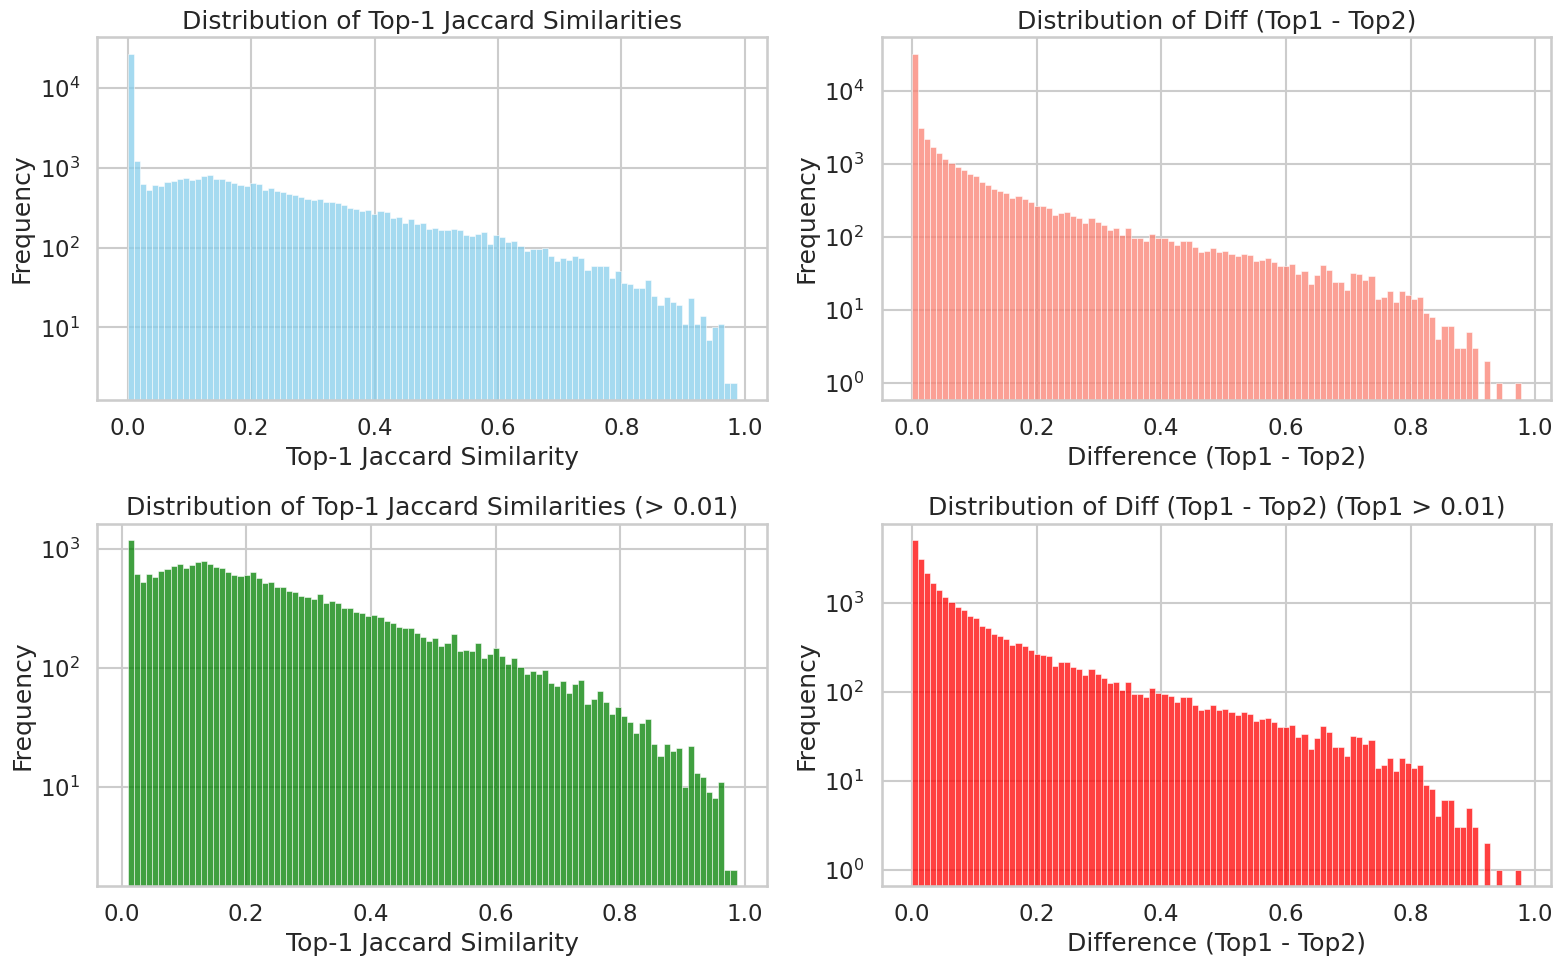

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid", context="talk")

df_non_zero = df[df['Top1_Jaccard'] > 0.01]

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

# --- Left plot: Top1 Jaccard Similarities ---
sns.histplot(df['Top1_Jaccard'], bins=100, kde=False, ax=axes[0], color="skyblue")
axes[0].set_yscale('log')
axes[0].set_title("Distribution of Top-1 Jaccard Similarities")
axes[0].set_xlabel("Top-1 Jaccard Similarity")
axes[0].set_ylabel("Frequency")

# --- Right plot: Difference between Top1 and Top2 ---
sns.histplot(df['Diff between Top1 and Top2'], bins=100, kde=False, ax=axes[1], color="salmon")
axes[1].set_yscale('log')
axes[1].set_title("Distribution of Diff (Top1 - Top2)")
axes[1].set_xlabel("Difference (Top1 - Top2)")
axes[1].set_ylabel("Frequency")

# --- Bottom Left: Zoomed Top1 Jaccard Similarities (non-zero) ---
sns.histplot(df_non_zero['Top1_Jaccard'], bins=100, kde=False, ax=axes[2], color="green")
axes[2].set_yscale('log')
axes[2].set_title("Distribution of Top-1 Jaccard Similarities (> 0.01)")
axes[2].set_xlabel("Top-1 Jaccard Similarity")
axes[2].set_ylabel("Frequency")

# --- Right plot: Difference between Top1 and Top2 ---
sns.histplot(df_non_zero['Diff between Top1 and Top2'], bins=100, kde=False, ax=axes[3], color="red")
axes[3].set_yscale('log')
axes[3].set_title("Distribution of Diff (Top1 - Top2) (Top1 > 0.01)")
axes[3].set_xlabel("Difference (Top1 - Top2)")
axes[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [3]:
df_filtered = df[df['Top1_Jaccard'] > 0.01]

# Assume your filtered DataFrame is called df_filtered
# (i.e., you've already kept rows where top1_jaccard >= 0.01)

threshold = 0.01

def filter_by_threshold(row):
    """
    Filters out Jaccard similarities below threshold
    and removes the corresponding Token IDs.
    """
    jaccards = eval(row['Jaccard Similarities'])
    tokens = eval(row['Token IDs'])
    
    # Make sure both are valid lists
    if not isinstance(jaccards, list) or not isinstance(tokens, list):
        return pd.Series([[], []])
    
    # Keep pairs where jaccard >= threshold
    filtered_pairs = [(t, j) for t, j in zip(tokens, jaccards) if j >= threshold]
    
    if filtered_pairs:
        tokens_filt, jaccards_filt = zip(*filtered_pairs)
    else:
        tokens_filt, jaccards_filt = [], []
    
    return pd.Series([list(tokens_filt), list(jaccards_filt)])

# Apply to your DataFrame
df_filtered[['Token IDs', 'Jaccard Similarities']] = df_filtered.apply(filter_by_threshold, axis=1)
df_filtered

/tmp/ipykernel_3521701/752252575.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[['Token IDs', 'Jaccard Similarities']] = df_filtered.apply(filter_by_threshold, axis=1)


,Latent ID,Token IDs,Jaccard Similarities,Diff between Top1 and Top2,Top1_Jaccard
1,2,[26550],[0.0196078431372549],0.018698,0.019608
2,4,"[19292, 26222, 10398]","[0.13114915387642662, 0.05240108728480822, 0.0...",0.078748,0.131149
3,5,"[10019, 4224, 15975]","[0.32532584879556753, 0.2600809739904635, 0.15...",0.065245,0.325326
6,8,"[28933, 26343, 13697]","[0.3899975761493092, 0.20822382365409073, 0.17...",0.181774,0.389998
7,9,"[30136, 1962]","[0.01694915254237288, 0.013157894736842105]",0.003791,0.016949
...,...,...,...,...,...
54582,65525,"[3822, 4243, 2283]","[0.12059420135128952, 0.09454353474601712, 0.0...",0.026051,0.120594
54584,65527,"[20448, 13357, 25204]","[0.24505525118395394, 0.1412282031842305, 0.12...",0.103827,0.245055
54586,65530,"[12367, 6727, 21672]","[0.1751650770359501, 0.12676728250498742, 0.11...",0.048398,0.175165
54587,65531,"[10765, 26500, 13073]","[0.21779559802081555, 0.1405803638550594, 0.08...",0.077215,0.217796


In [4]:
df_filtered = df_filtered[df_filtered['Token IDs'].apply(lambda x: len(x) > 0)]

In [5]:
df_filtered['Remaining_Token_Count'] = df_filtered['Token IDs'].apply(len)

# Compute the average (mean)
avg_remaining = df_filtered['Remaining_Token_Count'].mean()

print(f"Average number of remaining token IDs per row: {avg_remaining:.3f}")

Average number of remaining token IDs per row: 2.910


### Expand the list into different rows to check now if the average nb of token per latent has changed if we consider more pairs per latent

In [10]:
# Start from your filtered DataFrame
# Columns: ['Latent ID', 'Token IDs', 'Jaccard Similarities', ...]

# Make sure both list columns have the same length per row
assert all(df_filtered['Token IDs'].str.len() == df_filtered['Jaccard Similarities'].str.len()), \
    "Token ID and Jaccard Similarity list lengths do not match in some rows"

# Explode both columns in sync
df_expanded = df_filtered.explode(['Token IDs', 'Jaccard Similarities'], ignore_index=True)

# Optionally, rename for clarity
df_expanded = df_expanded.rename(columns={
    'Token IDs': 'Token ID',
    'Jaccard Similarities': 'Jaccard Similarity'
})

# Keep only the columns you care about
df_expanded = df_expanded[['Latent ID', 'Token ID', 'Jaccard Similarity']]

from transformers import AutoTokenizer
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

df_expanded['Token'] = df_expanded['Token ID'].apply(lambda x: tokenizer.convert_ids_to_tokens(x))


In [12]:
df_expanded.head(50)

,Latent ID,Token ID,Jaccard Similarity,Token
0,2,26550,0.019608,brentford
1,4,19292,0.131149,morale
2,4,26222,0.052401,croats
3,4,10398,0.040719,propaganda
4,5,10019,0.325326,zones
5,5,4224,0.260081,zone
6,5,15975,0.156892,##zone
7,8,28933,0.389998,magma
8,8,26343,0.208224,basalt
9,8,13697,0.171122,lava


In [18]:
# Get all token IDs from the tokenizer vocabulary
all_token_ids = set(range(tokenizer.vocab_size))

# Get the token IDs present in your expanded dataframe
present_token_ids = set(df_expanded['Token ID'].unique())

# Find missing ones
missing_token_ids = sorted(all_token_ids - present_token_ids)

print(f"Total missing tokens: {len(missing_token_ids)} ({len(missing_token_ids) / tokenizer.vocab_size:.2%} of vocab)")

# Optionally convert to readable tokens
missing_tokens = tokenizer.convert_ids_to_tokens(missing_token_ids)

# Create a dataframe for inspection
missing_df = pd.DataFrame({
    'Token ID': missing_token_ids,
    'Token': missing_tokens
})

print(missing_df.head(20))
print(missing_df.tail(20))


Total missing tokens: 4971 (16.29% of vocab)
    Token ID       Token
0          0       [PAD]
1          1   [unused0]
2          2   [unused1]
3          3   [unused2]
4          4   [unused3]
5          5   [unused4]
6          6   [unused5]
7          7   [unused6]
8          8   [unused7]
9          9   [unused8]
10        10   [unused9]
11        11  [unused10]
12        12  [unused11]
13        13  [unused12]
14        14  [unused13]
15        15  [unused14]
16        16  [unused15]
17        17  [unused16]
18        18  [unused17]
19        19  [unused18]
      Token ID Token
4951     30500   ##雄
4952     30501   ##青
4953     30502   ##面
4954     30503   ##風
4955     30504   ##食
4956     30505   ##香
4957     30506   ##馬
4958     30507   ##高
4959     30508   ##龍
4960     30509   ##龸
4961     30511   ##ﬂ
4962     30512   ##！
4963     30513   ##（
4964     30514   ##）
4965     30515   ##，
4966     30516   ##－
4967     30517   ##．
4968     30518   ##／
4969     30519   ##：
4970     3

## We saw one side of the coin (some latents seem to summarize multiple tokens sharing a common semantic concept). Now we need to check the second side of the coin, i.e., are two or more latents mapped to single tokens or not?

In [5]:
import numpy as np

jaccard = np.load('jaccard_matrix.npy')

In [2]:
jaccard.shape

(54608, 30186)

In [6]:

import numpy as np

top_k = 3

# Assume `jaccard` has shape (num_latents, num_tokens)
# We want top 3 latents per token → sort along axis=0 (rows)

top_idx = np.argsort(jaccard, axis=0)[-top_k:][::-1, :]  # shape: (3, num_tokens)

# Corresponding top Jaccard scores
top_scores = np.take_along_axis(jaccard, top_idx, axis=0)  # shape: (3, num_tokens)

# Map token IDs to list of (latent ID, score) tuples
latent_ids = list(latent_to_docids.keys())
token_ids = list(token_to_docids.keys())

mapping_top3_tokens = {
    token_ids[j]: [
        (latent_ids[top_idx[i, j]], top_scores[i, j])
        for i in range(top_k)
    ]
    for j in range(len(token_ids))
}


In [7]:
import pandas as pd

# Build DataFrame with lists of token IDs and scores
df_top3 = pd.DataFrame([
    {
        "Token ID": token_id,
        "Latent IDs": [t for t, s in top_list],             # list of token IDs
        "Jaccard Similarities": [s for t, s in top_list]  # list of corresponding scores
    }
    for token_id, top_list in mapping_top3_tokens.items()
])

# Save to CSV
df_top3.to_csv("top3_jaccard_similarity_token_to_latents.csv", index=False)

print(df_top3)

       Token ID             Latent IDs  \
0           100  [45654, 39425, 37438]   
1           101   [5257, 63938, 14144]   
2           999  [43565, 19024, 28136]   
3          1000  [33563, 28506, 18907]   
4          1001  [58510, 34843, 51122]   
...         ...                    ...   
28993     30501  [44796, 20021, 35481]   
28994     30508   [8511, 12382, 36724]   
28995     30510  [56313, 28576, 12206]   
28996     30511  [18487, 52626, 16553]   
28997     30521  [56159, 52780, 52030]   

                                    Jaccard Similarities  
0      [0.05451090035268534, 0.041513360835470324, 0....  
1      [0.01658196451182072, 0.015514625305571947, 0....  
2      [0.04057574358636154, 0.03006610729722858, 0.0...  
3      [0.045454545454545456, 0.013513513513513514, 0...  
4      [0.13231023256903296, 0.0870684391000047, 0.08...  
...                                                  ...  
28993  [0.0005099439061703213, 0.00026910656620021526...  
28994  [0.0009354536950

In [2]:
import pandas as pd
df_top3 = pd.read_csv("top3_jaccard_similarity_token_to_latents.csv")

In [3]:
df_top3["Diff between Top1 and Top2"] = df_top3['Jaccard Similarities'].apply(lambda x: eval(x)[0] - eval(x)[1] if isinstance(eval(x), list) and len(eval(x)) > 1 else None)
df_top3['Top1_Jaccard'] = df_top3['Jaccard Similarities'].apply(lambda x: eval(x)[0] if isinstance(eval(x), list) and len(eval(x)) > 0 else None)
df_top3

,Token ID,Latent IDs,Jaccard Similarities,Diff between Top1 and Top2,Top1_Jaccard
0,100,"[45654, 39425, 37438]","[0.05451090035268534, 0.041513360835470324, 0....",0.012998,0.054511
1,101,"[5257, 63938, 14144]","[0.01658196451182072, 0.015514625305571947, 0....",0.001067,0.016582
2,999,"[43565, 19024, 28136]","[0.04057574358636154, 0.03006610729722858, 0.0...",0.010510,0.040576
3,1000,"[33563, 28506, 18907]","[0.045454545454545456, 0.013513513513513514, 0...",0.031941,0.045455
4,1001,"[58510, 34843, 51122]","[0.13231023256903296, 0.0870684391000047, 0.08...",0.045242,0.132310
...,...,...,...,...,...
28993,30501,"[44796, 20021, 35481]","[0.0005099439061703213, 0.00026910656620021526...",0.000241,0.000510
28994,30508,"[8511, 12382, 36724]","[0.0009354536950420954, 0.0009163103237629811,...",0.000019,0.000935
28995,30510,"[56313, 28576, 12206]","[0.06522039519137764, 0.06209206954311789, 0.0...",0.003128,0.065220
28996,30511,"[18487, 52626, 16553]","[0.022910065805508164, 0.02092966658554393, 0....",0.001980,0.022910


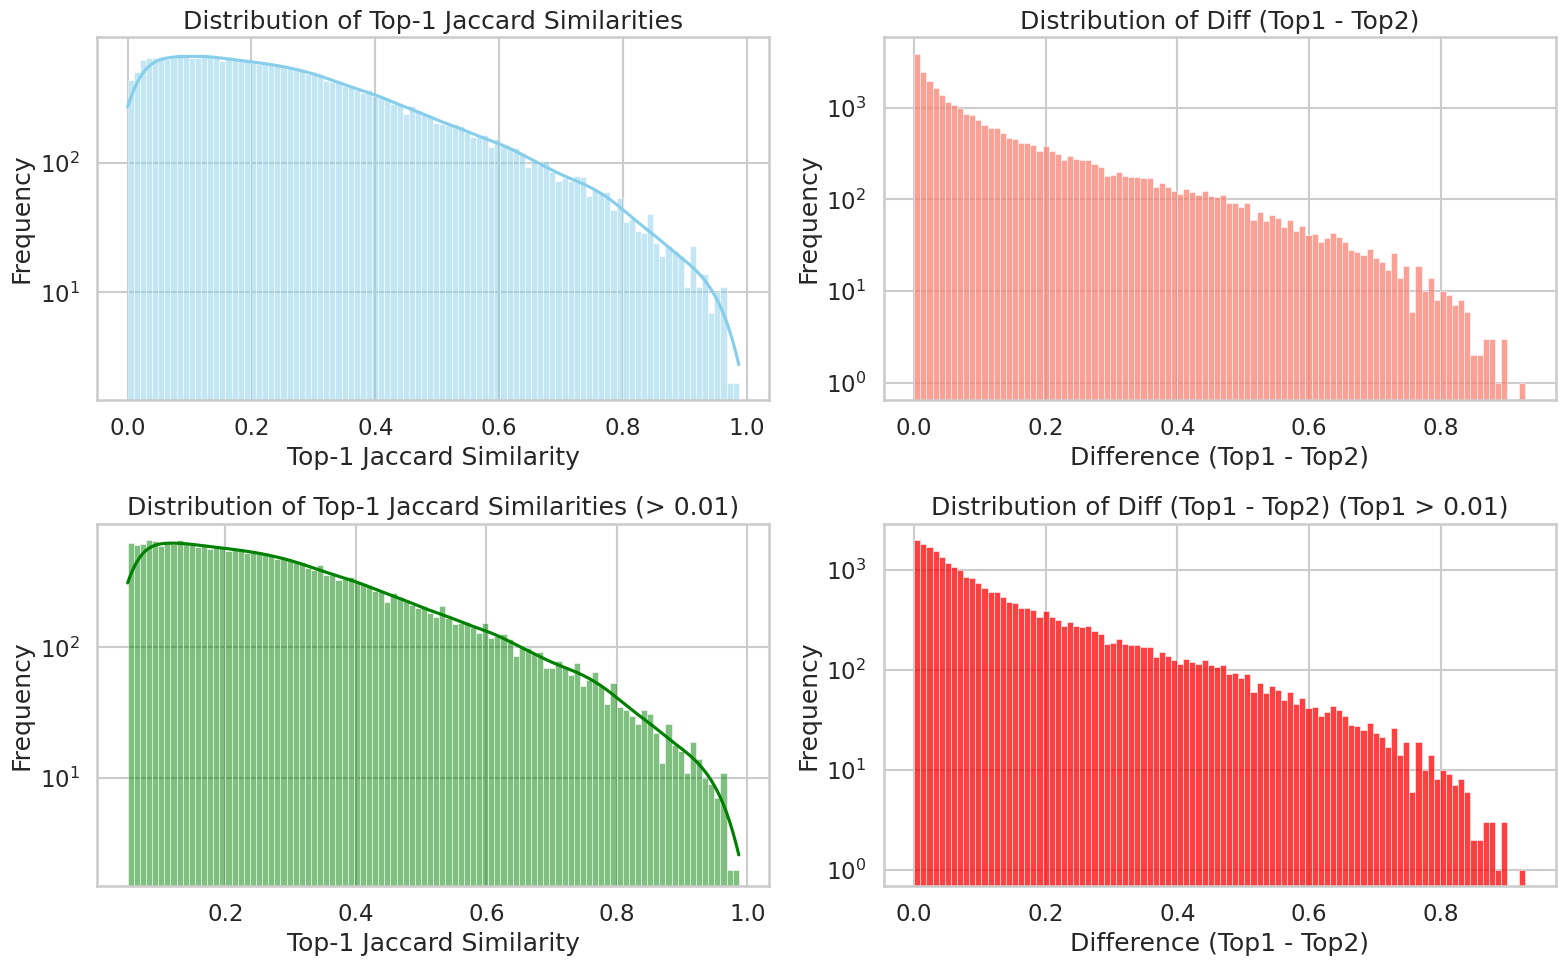

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid", context="talk")

df_non_zero = df_top3[df_top3['Top1_Jaccard'] > 0.05]

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

# --- Left plot: Top1 Jaccard Similarities ---
sns.histplot(df_top3['Top1_Jaccard'], bins=100, kde=True, ax=axes[0], color="skyblue")
axes[0].set_yscale('log')
axes[0].set_title("Distribution of Top-1 Jaccard Similarities")
axes[0].set_xlabel("Top-1 Jaccard Similarity")
axes[0].set_ylabel("Frequency")

# --- Right plot: Difference between Top1 and Top2 ---
sns.histplot(df_top3['Diff between Top1 and Top2'], bins=100, kde=False, ax=axes[1], color="salmon")
axes[1].set_yscale('log')
axes[1].set_title("Distribution of Diff (Top1 - Top2)")
axes[1].set_xlabel("Difference (Top1 - Top2)")
axes[1].set_ylabel("Frequency")

# --- Bottom Left: Zoomed Top1 Jaccard Similarities (non-zero) ---
sns.histplot(df_non_zero['Top1_Jaccard'], bins=100, kde=True, ax=axes[2], color="green")
axes[2].set_yscale('log')
axes[2].set_title("Distribution of Top-1 Jaccard Similarities (> 0.01)")
axes[2].set_xlabel("Top-1 Jaccard Similarity")
axes[2].set_ylabel("Frequency")

# --- Right plot: Difference between Top1 and Top2 ---
sns.histplot(df_non_zero['Diff between Top1 and Top2'], bins=100, kde=False, ax=axes[3], color="red")
axes[3].set_yscale('log')
axes[3].set_title("Distribution of Diff (Top1 - Top2) (Top1 > 0.01)")
axes[3].set_xlabel("Difference (Top1 - Top2)")
axes[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [5]:
df_filtered = df_top3[df_top3['Top1_Jaccard'] > 0.05]

# Assume your filtered DataFrame is called df_filtered
# (i.e., you've already kept rows where top1_jaccard >= 0.01)

threshold = 0.01

def filter_by_threshold(row):
    """
    Filters out Jaccard similarities below threshold
    and removes the corresponding Latent IDs.
    """
    jaccards = eval(row['Jaccard Similarities'])
    tokens = eval(row['Latent IDs'])
    
    # Make sure both are valid lists
    if not isinstance(jaccards, list) or not isinstance(tokens, list):
        return pd.Series([[], []])
    
    # Keep pairs where jaccard >= threshold
    filtered_pairs = [(t, j) for t, j in zip(tokens, jaccards) if j >= threshold]
    
    if filtered_pairs:
        tokens_filt, jaccards_filt = zip(*filtered_pairs)
    else:
        tokens_filt, jaccards_filt = [], []
    
    return pd.Series([list(tokens_filt), list(jaccards_filt)])

# Apply to your DataFrame
df_filtered[['Latent IDs', 'Jaccard Similarities']] = df_filtered.apply(filter_by_threshold, axis=1)
df_filtered = df_filtered[df_filtered['Latent IDs'].apply(lambda x: len(x) > 0)]
df_filtered

/tmp/ipykernel_3686664/994643966.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[['Latent IDs', 'Jaccard Similarities']] = df_filtered.apply(filter_by_threshold, axis=1)


,Token ID,Latent IDs,Jaccard Similarities,Diff between Top1 and Top2,Top1_Jaccard
0,100,"[45654, 39425, 37438]","[0.05451090035268534, 0.041513360835470324, 0....",0.012998,0.054511
4,1001,"[58510, 34843, 51122]","[0.13231023256903296, 0.0870684391000047, 0.08...",0.045242,0.132310
5,1002,"[33746, 22516, 37862]","[0.2848435814455232, 0.23670900343061632, 0.23...",0.048135,0.284844
6,1003,"[43373, 20919, 26333]","[0.7504836413936891, 0.2201756897253153, 0.215...",0.530308,0.750484
7,1004,"[1677, 12297, 53369]","[0.19943347885359036, 0.16519378194207837, 0.0...",0.034240,0.199433
...,...,...,...,...,...
28877,30214,"[22994, 52282, 15496]","[0.09090909090909091, 0.046511627906976744, 0....",0.044397,0.090909
28895,30232,"[64585, 38372, 63115]","[0.16723350500437276, 0.04583362534164973, 0.0...",0.121400,0.167234
28915,30252,"[40574, 57237, 59418]","[0.06512605042016807, 0.03259259259259259, 0.0...",0.032533,0.065126
28935,30299,[18484],[0.125],0.124323,0.125000


In [6]:
df_filtered['Remaining_Latent_Count'] = df_filtered['Latent IDs'].apply(len)

# Compute the average (mean)
avg_remaining = df_filtered['Remaining_Latent_Count'].mean()

print(f"Average number of remaining latent IDs per row: {avg_remaining:.3f}")

Average number of remaining latent IDs per row: 2.989


In [ ]:
# Start from your filtered DataFrame
# Columns: ['Latent ID', 'Token IDs', 'Jaccard Similarities', ...]

# Make sure both list columns have the same length per row
assert all(df_filtered['Latent IDs'].str.len() == df_filtered['Jaccard Similarities'].str.len()), \
    "Latent ID and Jaccard Similarity list lengths do not match in some rows"

# Explode both columns in sync
df_expanded = df_filtered.explode(['Latent IDs', 'Jaccard Similarities'], ignore_index=True)

# Optionally, rename for clarity
df_expanded = df_expanded.rename(columns={
    'Latent IDs': 'Latent ID',
    'Jaccard Similarities': 'Jaccard Similarity'
})

# Keep only the columns you care about
df_expanded = df_expanded[['Token ID', 'Latent ID', 'Jaccard Similarity']]

from transformers import AutoTokenizer
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

df_expanded['Token'] = df_expanded['Token ID'].apply(lambda x: tokenizer.convert_ids_to_tokens(x))


In [8]:
df_expanded[df_expanded['Token ID'] >= 5000].head(50)

,Token ID,Latent ID,Jaccard Similarity,Token
9596,5000,56463,0.774918,knight
9597,5000,62665,0.31958,knight
9598,5000,14343,0.052422,knight
9599,5001,50942,0.39967,lap
9600,5001,59118,0.093603,lap
9601,5001,3790,0.059561,lap
9602,5002,59970,0.308715,survey
9603,5002,58532,0.099474,survey
9604,5002,55362,0.092968,survey
9605,5003,47699,0.426546,ma


In [9]:
import numpy as np

df_filtered["Mean Jaccard Similarity"] = df_filtered['Jaccard Similarities'].apply(lambda x: np.mean(x) if isinstance(x, list) and len(x) > 0 else None)
df_filtered

,Token ID,Latent IDs,Jaccard Similarities,Diff between Top1 and Top2,Top1_Jaccard,Remaining_Latent_Count,Mean Jaccard Similarity
0,100,"[45654, 39425, 37438]","[0.05451090035268534, 0.041513360835470324, 0....",0.012998,0.054511,3,0.045128
4,1001,"[58510, 34843, 51122]","[0.13231023256903296, 0.0870684391000047, 0.08...",0.045242,0.132310,3,0.100102
5,1002,"[33746, 22516, 37862]","[0.2848435814455232, 0.23670900343061632, 0.23...",0.048135,0.284844,3,0.250940
6,1003,"[43373, 20919, 26333]","[0.7504836413936891, 0.2201756897253153, 0.215...",0.530308,0.750484,3,0.395481
7,1004,"[1677, 12297, 53369]","[0.19943347885359036, 0.16519378194207837, 0.0...",0.034240,0.199433,3,0.148142
...,...,...,...,...,...,...,...
28877,30214,"[22994, 52282, 15496]","[0.09090909090909091, 0.046511627906976744, 0....",0.044397,0.090909,3,0.055066
28895,30232,"[64585, 38372, 63115]","[0.16723350500437276, 0.04583362534164973, 0.0...",0.121400,0.167234,3,0.084036
28915,30252,"[40574, 57237, 59418]","[0.06512605042016807, 0.03259259259259259, 0.0...",0.032533,0.065126,3,0.037704
28935,30299,[18484],[0.125],0.124323,0.125000,1,0.125000


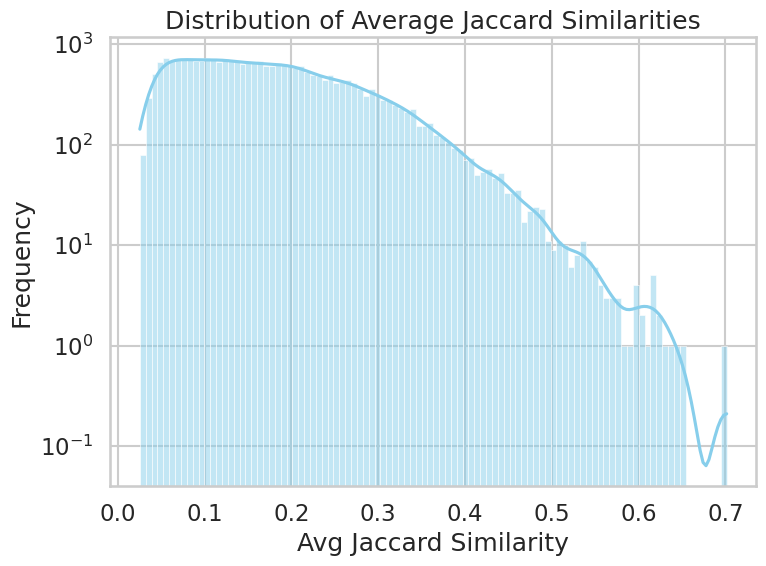

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid", context="talk")

# Create a 2x2 subplot layout
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

# --- Left plot: Top1 Jaccard Similarities ---
sns.histplot(df_filtered['Mean Jaccard Similarity'], bins=100, kde=True, ax=axes, color="skyblue")
axes.set_yscale('log')
axes.set_title("Distribution of Average Jaccard Similarities")
axes.set_xlabel("Avg Jaccard Similarity")
axes.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [12]:
# Sort by High_Sim_Latent_Count descending
df_filtered["Token"] = df_filtered['Token ID'].apply(lambda x: tokenizer.convert_ids_to_tokens(x))
df_filtered.sort_values(by='Mean Jaccard Similarity', ascending=False).reset_index(drop=True).head(100)


,Token ID,Latent IDs,Jaccard Similarities,Diff between Top1 and Top2,Top1_Jaccard,Remaining_Latent_Count,Mean Jaccard Similarity,Token
0,27869,"[44395, 1903, 49394]","[0.9519854132901134, 0.8316614991792814, 0.320...",0.120324,0.951985,3,0.701496,##anor
1,28522,"[2798, 25681, 36388]","[0.9550481114462157, 0.6070593238358495, 0.386...",0.347989,0.955048,3,0.649676,##bla
2,7265,"[20862, 34148, 27819]","[0.9649415022776986, 0.596065706753194, 0.3644...",0.368876,0.964942,3,0.641813,##dra
3,24385,"[4004, 48163, 17288]","[0.862133081354589, 0.659268962390105, 0.38581...",0.202864,0.862133,3,0.635738,dentist
4,16480,"[38369, 41477, 30347]","[0.9248344289336977, 0.5065681840053893, 0.463...",0.418266,0.924834,3,0.631573,cho
...,...,...,...,...,...,...,...,...
95,10250,"[30365, 42479, 37100]","[0.7519299458462957, 0.395403538291998, 0.3596...",0.356526,0.751930,3,0.502338,cal
96,28915,"[33521, 11700, 36226]","[0.7483251895907493, 0.38495117634190484, 0.37...",0.363374,0.748325,3,0.501713,arteries
97,7828,"[55625, 39895, 44917]","[0.5960417305922062, 0.4614740049514378, 0.447...",0.134568,0.596042,3,0.501547,##oon
98,3096,"[36506, 5293, 27732]","[0.7740544127405441, 0.41403078335157273, 0.31...",0.360024,0.774054,3,0.500542,skin
